In [74]:
#Se importan las librerias a utilizar

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
%matplotlib inline

In [75]:
import chardet

#Carga de datos

with open("CasasEnVenta_Madrid_NotOutliers.csv", "rb") as f:
    result = chardet.detect(f.read())
    encoding_detected = result["encoding"]

data_kdd = pd.read_csv("CasasEnVenta_Madrid_NotOutliers.csv", encoding=encoding_detected, sep=';', index_col='id')
print(data_kdd.head(5))

     precio  metros_cuadrados_totales  metros_cuadrados_utiles  numero_baNos  \
id                                                                             
1    650000                        78                       78             1   
2    525000                        70                       62             1   
3    795000                       127                      113             2   
4   3650000                       304                      290             5   
5   5100000                       310                      270             5   

    numero_habitaciones  planta  antigUedad vivienda_unifamiliar  \
id                                                                 
1                     2       2          66                   No   
2                     1       4          57                   No   
3                     5       4          54                   No   
4                     4       5          85                   No   
5                     4       6

In [76]:
# Vista de los tipos de datos y el tamaño del dataset (filas/registros y columnas/atributos).

data_kdd.info()

print("-------------------------------------")
print(f"Cantidad de filas: {data_kdd.shape[0]}")
print(f"Cantidad de columnas: {data_kdd.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
Index: 16923 entries, 1 to 19444
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   precio                    16923 non-null  int64 
 1   metros_cuadrados_totales  16923 non-null  int64 
 2   metros_cuadrados_utiles   16923 non-null  int64 
 3   numero_baNos              16923 non-null  int64 
 4   numero_habitaciones       16923 non-null  int64 
 5   planta                    16923 non-null  int64 
 6   antigUedad                16923 non-null  int64 
 7   vivienda_unifamiliar      16923 non-null  object
 8   tipo_vivienda             16923 non-null  object
 9   estado                    16923 non-null  object
 10  interior                  16923 non-null  object
 11  ascensor                  16923 non-null  object
 12  piscina                   16923 non-null  object
 13  trastero                  16923 non-null  object
 14  garaje                    1

VARIABLES NUMÉRCIAS

In [77]:
#convertimos la variable "postal_code" a texto ya que es una variable geo y no numérica.

data_kdd['postal_code'] = data_kdd['postal_code'].astype(str)

var_numericas_tipos = data_kdd.select_dtypes(include=[np.number]).dtypes
print("VARIABLES NUMÉRICAS:\n")
print(var_numericas_tipos)

VARIABLES NUMÉRICAS:

precio                      int64
metros_cuadrados_totales    int64
metros_cuadrados_utiles     int64
numero_baNos                int64
numero_habitaciones         int64
planta                      int64
antigUedad                  int64
dtype: object


EMPEZAMOS A ANALIZAR CADA VARIABLE DE UNA EN UNA VARIABLE

# Vamos a ver el análisis completo de cada caraterística.

In [78]:
var_numericas = data_kdd.select_dtypes(include=[np.number]).columns

for var in  var_numericas:

    print("Característica:", var, "\n\n",data_kdd[var].describe().T,"\n\n\n") 

Característica: precio 

 count    1.692300e+04
mean     8.309689e+05
std      8.531973e+05
min      3.500000e+04
25%      2.700000e+05
50%      4.950000e+05
75%      1.100000e+06
max      5.400000e+06
Name: precio, dtype: float64 



Característica: metros_cuadrados_totales 

 count    16923.000000
mean       179.807363
std        153.416490
min         40.000000
25%         83.000000
50%        127.000000
75%        222.000000
max       2800.000000
Name: metros_cuadrados_totales, dtype: float64 



Característica: metros_cuadrados_utiles 

 count    16923.000000
mean       169.763872
std        143.624298
min         40.000000
25%         78.000000
50%        119.000000
75%        210.000000
max       1000.000000
Name: metros_cuadrados_utiles, dtype: float64 



Característica: numero_baNos 

 count    16923.000000
mean         2.380724
std          1.375620
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         10.000000
Name: numero_baNo

In [79]:
# Iteramos sobre cada variable
for var in var_numericas:
    print(f"\n### Estadísticas para ", var.upper(), " por tipo de vivienda ###\n")
    
    # Agrupamos por tipo de vivienda y calculamos min, mean y max
    resumen = data_kdd.groupby('tipo_vivienda')[var].agg(['min','mean','max'])

    # Redondeamos solo la media a 3 decimales
    resumen['mean'] = resumen['mean'].round(3)
    
    # Mostramos la tabla
    display(resumen)
    
    # Opcional: mostramos también los valores para todo el dataset
    resumen_total = data_kdd[var].agg(['min','mean','max']).to_frame().T
    resumen_total.index = ['Total']
    display(resumen_total)


### Estadísticas para  PRECIO  por tipo de vivienda ###



,min,mean,max
tipo_vivienda,,,
Casa de Pueblo,37000,286079.255,1950000
Chalet,35000,884661.267,5000000
Dúplex,55000,693848.018,4800000
Estudio,60000,301669.275,999999
Finca Rústica,69000,685543.189,3400000
Loft,155500,322268.444,590000
Piso,42000,812802.522,5400000
Ático,69700,1067511.001,5100000


,min,mean,max
Total,35000.0,830968.857708,5400000.0



### Estadísticas para  METROS_CUADRADOS_TOTALES  por tipo de vivienda ###



,min,mean,max
tipo_vivienda,,,
Casa de Pueblo,45,250.032,950
Chalet,40,324.596,2500
Dúplex,40,150.436,900
Estudio,40,65.113,300
Finca Rústica,50,362.149,2800
Loft,41,76.667,166
Piso,40,121.370,894
Ático,40,146.943,590


...

,min,mean,max
tipo_vivienda,,,
Casa de Pueblo,0,0.915,3
Chalet,0,0.705,5
Dúplex,0,2.162,10
Estudio,0,1.521,10
Finca Rústica,0,0.905,3
Loft,0,3.056,9
Piso,0,2.327,10
Ático,0,4.939,10


,min,mean,max
Total,0.0,1.992968,10.0



### Estadísticas para  ANTIGUEDAD  por tipo de vivienda ###



,min,mean,max
tipo_vivienda,,,
Casa de Pueblo,1,55.245,125
Chalet,0,29.158,225
Dúplex,0,31.171,175
Estudio,0,40.254,125
Finca Rústica,2,35.149,108
Loft,0,53.778,175
Piso,0,51.842,205
Ático,0,39.724,175


,min,mean,max
Total,0.0,44.046268,225.0


In [80]:
# Agrupamos por tipo_vivienda y calculamos min, mean y max
tabla_por_tipo = data_kdd.groupby('tipo_vivienda')[var_numericas].agg(['min','mean','max'])

# Redondeamos los valores a 3 decimales
tabla_por_tipo = tabla_por_tipo.round(3)

# Mostrar
print(tabla_por_tipo)

                precio                       metros_cuadrados_totales  \
                   min         mean      max                      min   
tipo_vivienda                                                           
Casa de Pueblo   37000   286079.255  1950000                       45   
Chalet           35000   884661.267  5000000                       40   
Dúplex           55000   693848.018  4800000                       40   
Estudio          60000   301669.275   999999                       40   
Finca Rústica    69000   685543.189  3400000                       50   
Loft            155500   322268.444   590000                       41   
Piso             42000   812802.522  5400000                       40   
Ático            69700  1067511.001  5100000                       40   

                              metros_cuadrados_utiles                 \
                   mean   max                     min     mean   max   
tipo_vivienda                                       

**Análisis de las Variables Categóricas.**

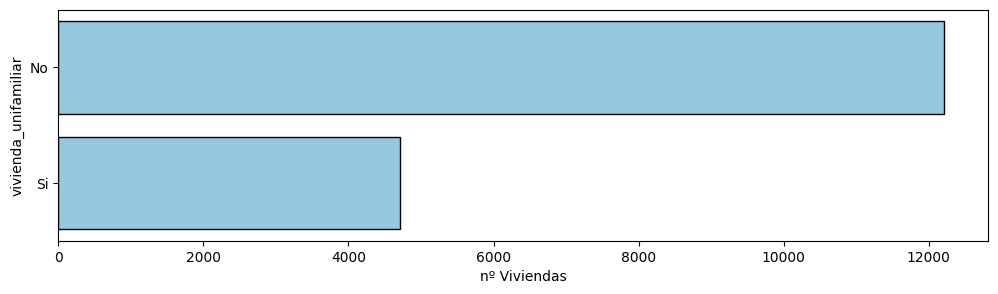

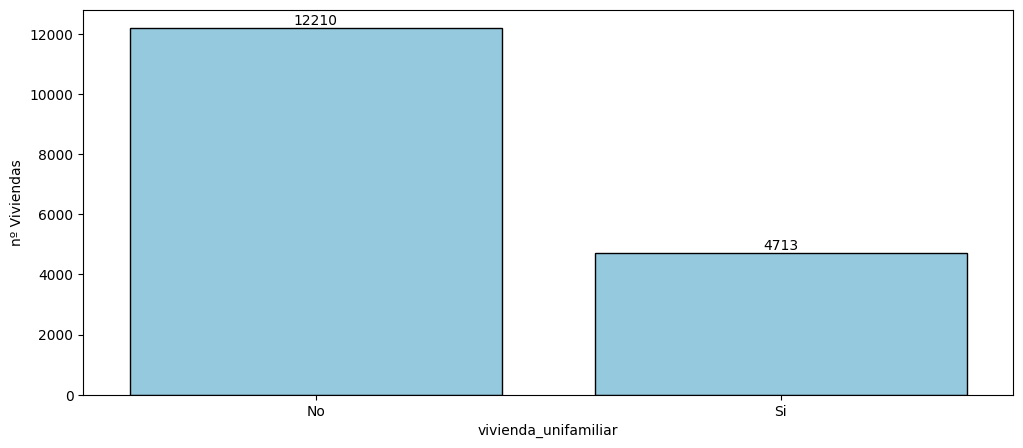

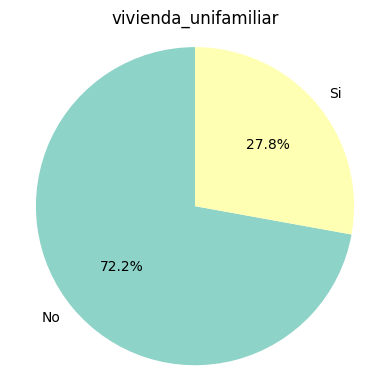

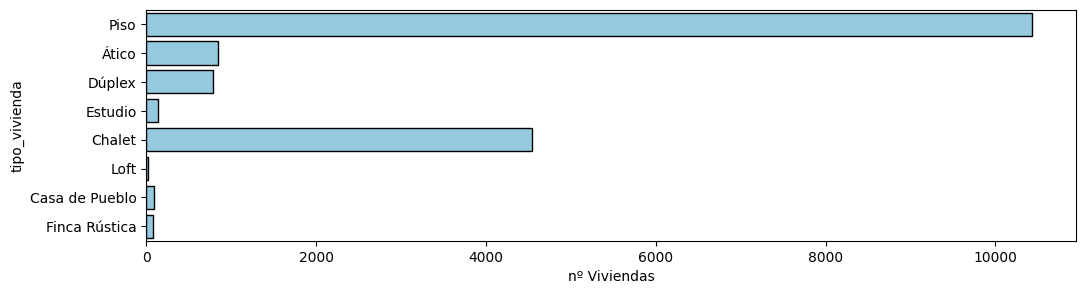

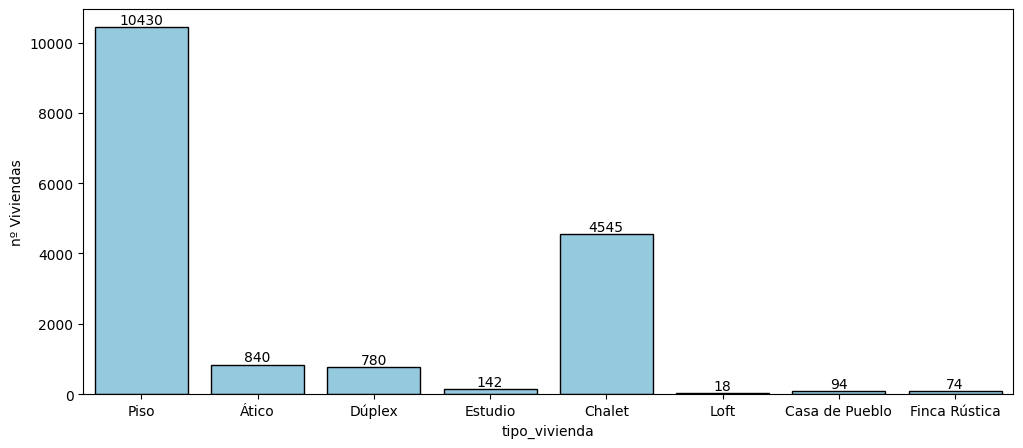

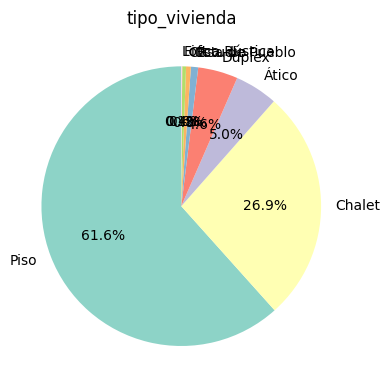

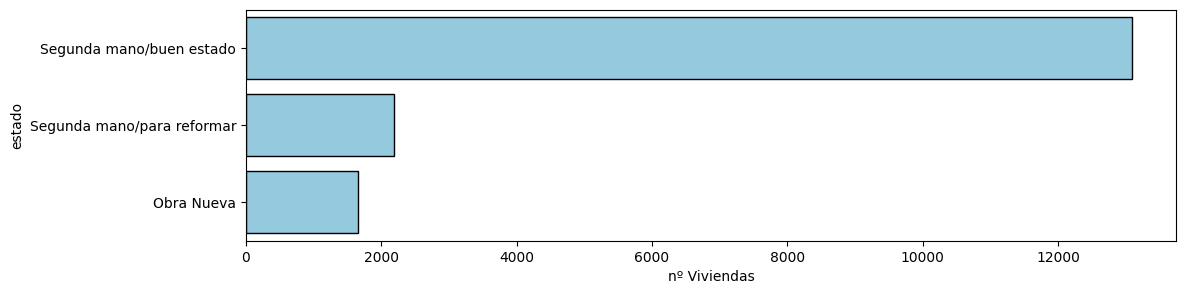

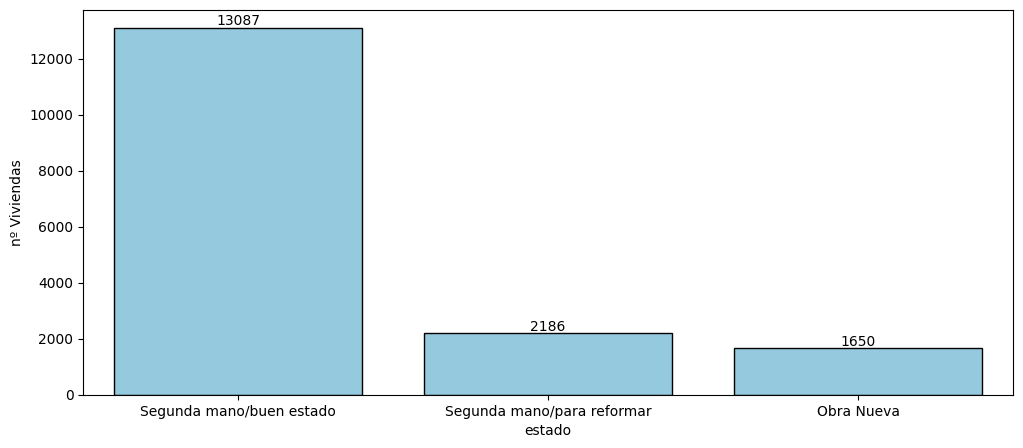

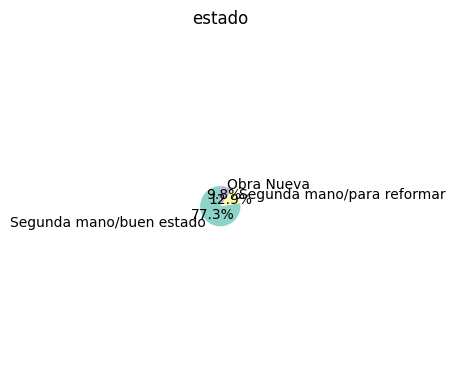

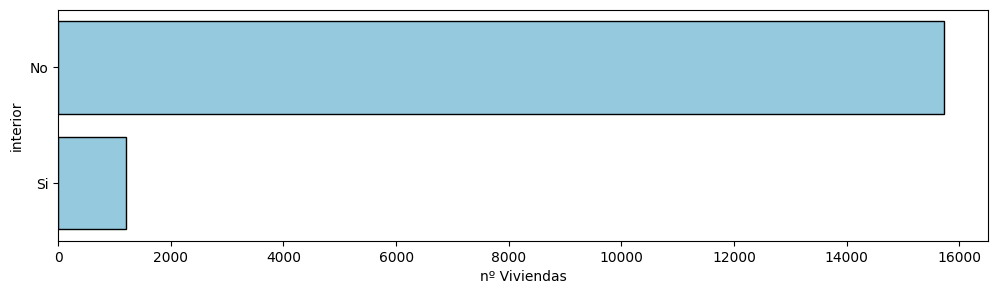

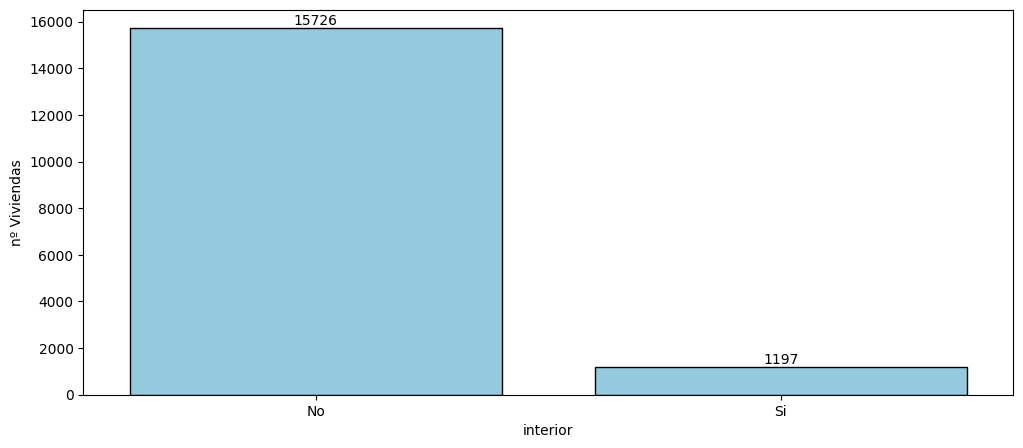

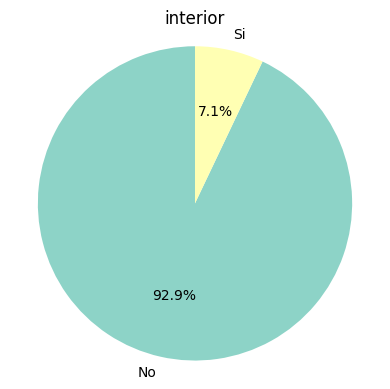

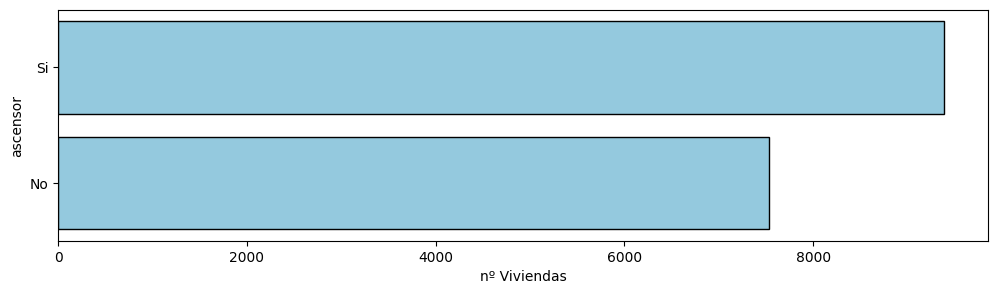

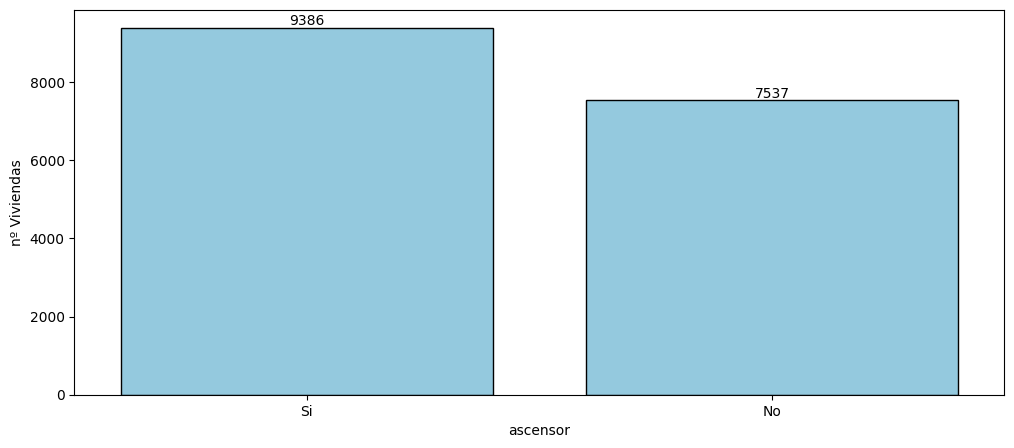

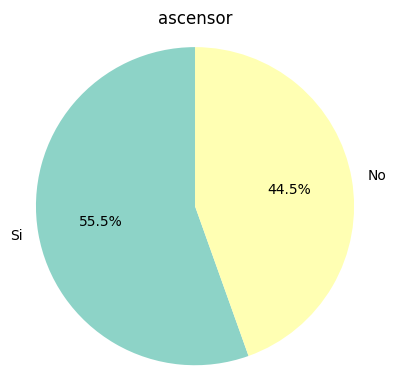

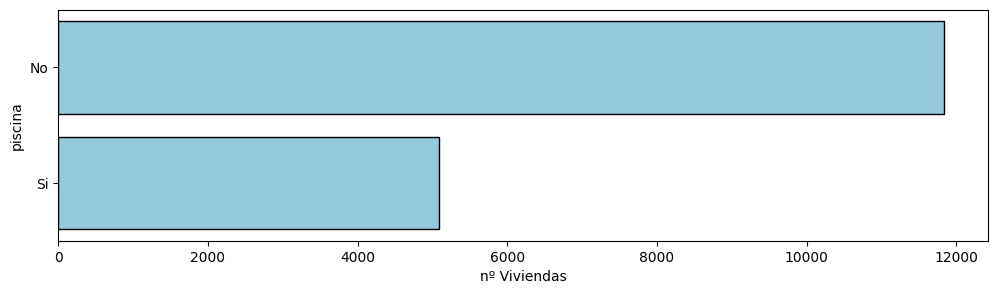

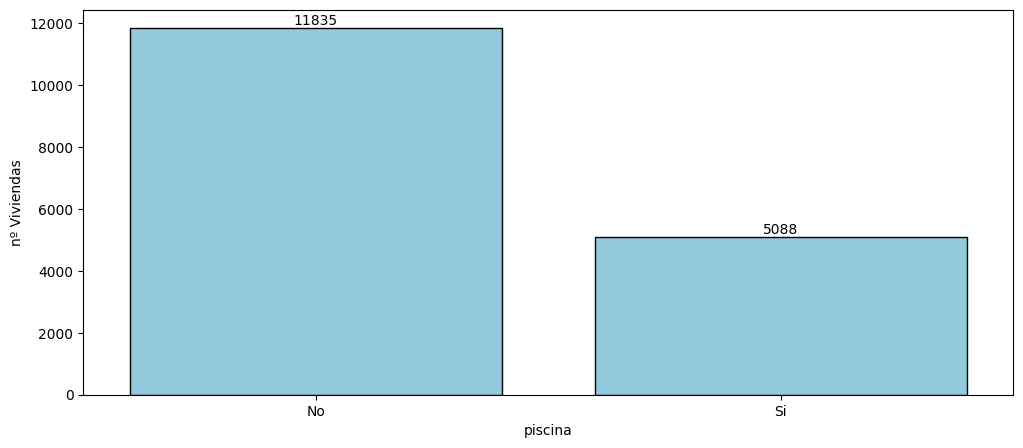

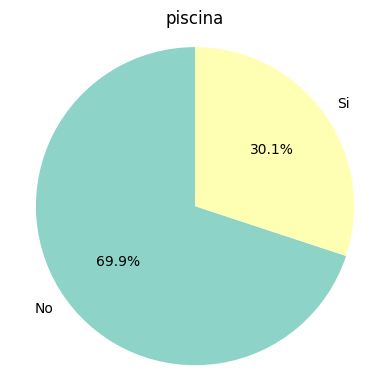

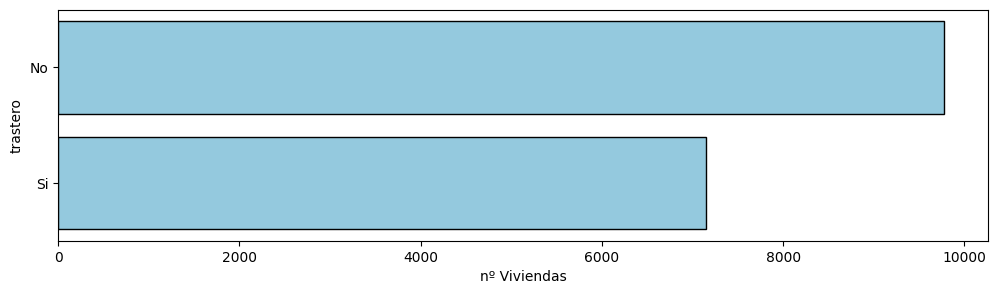

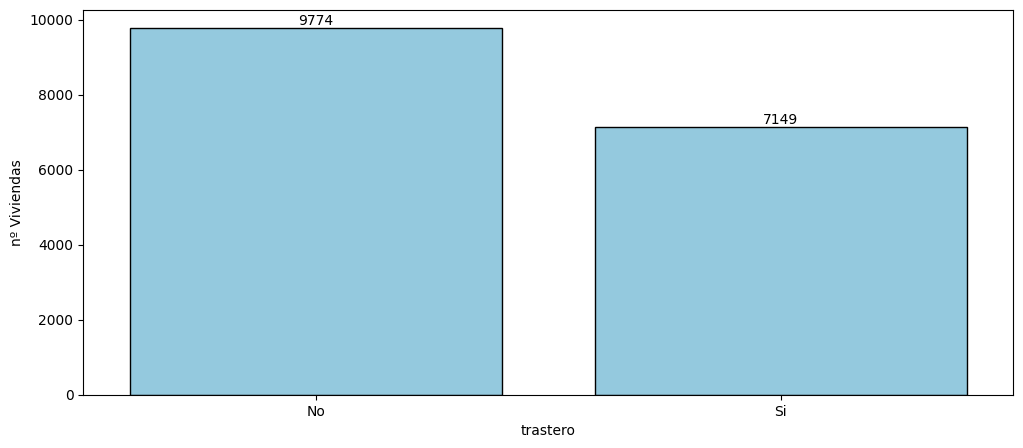

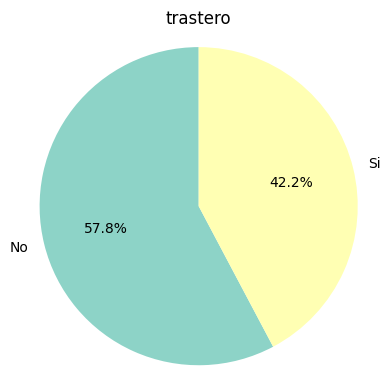

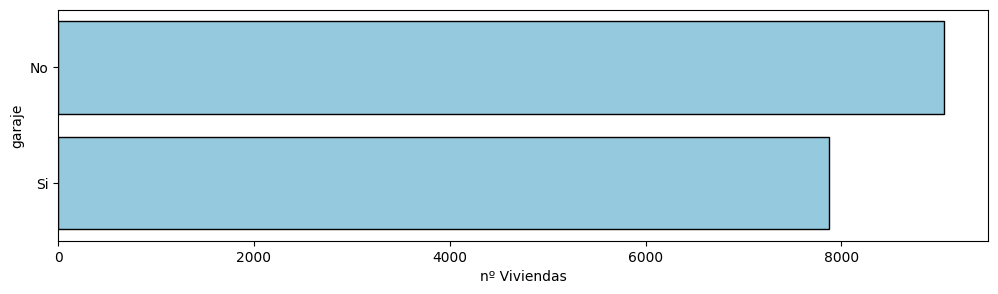

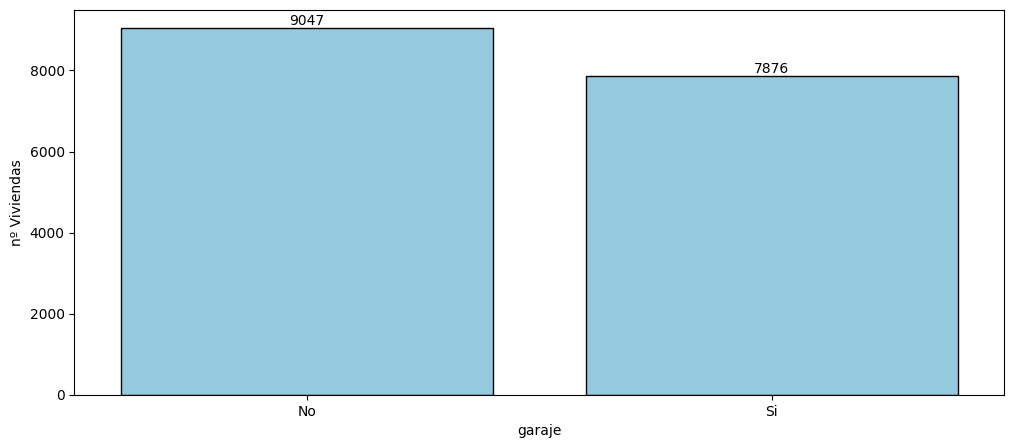

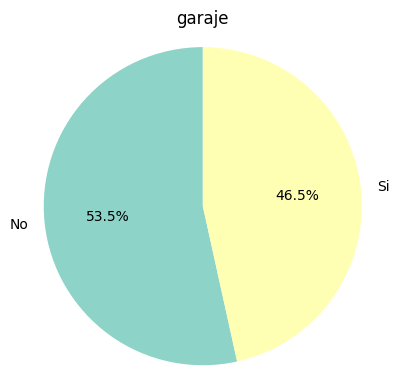

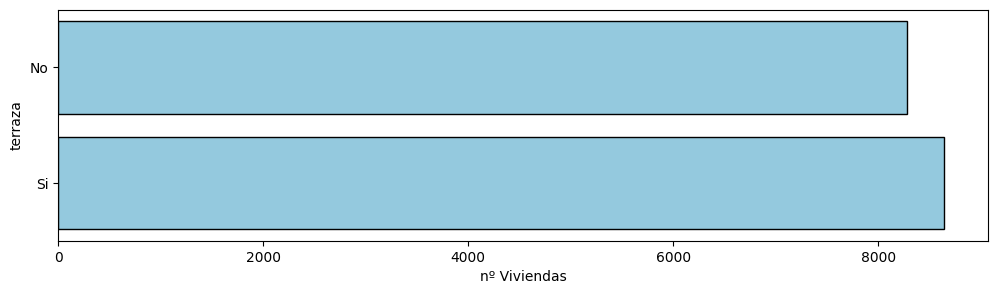

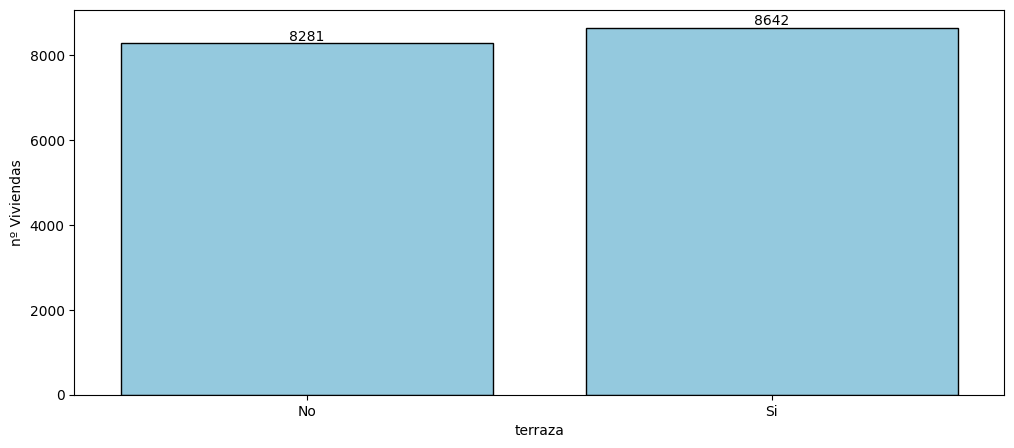

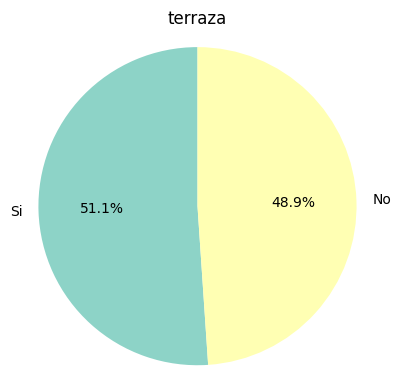

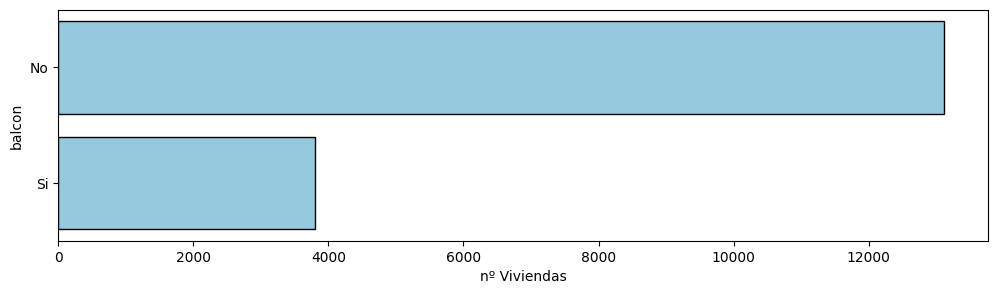

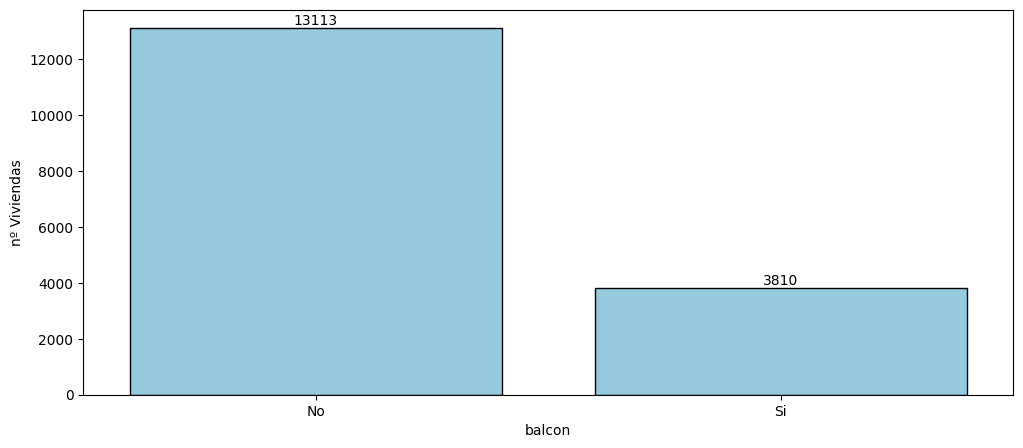

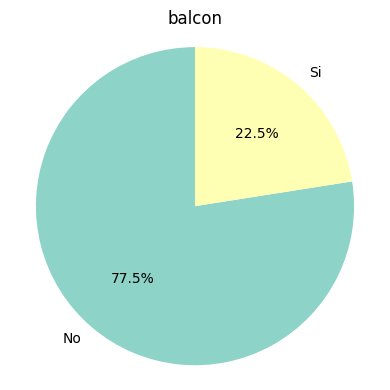

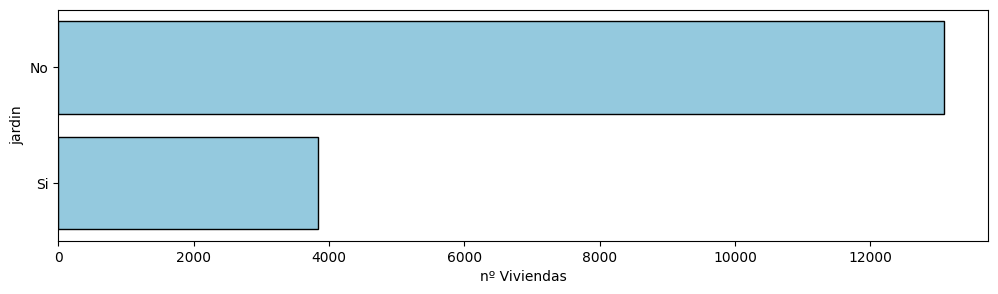

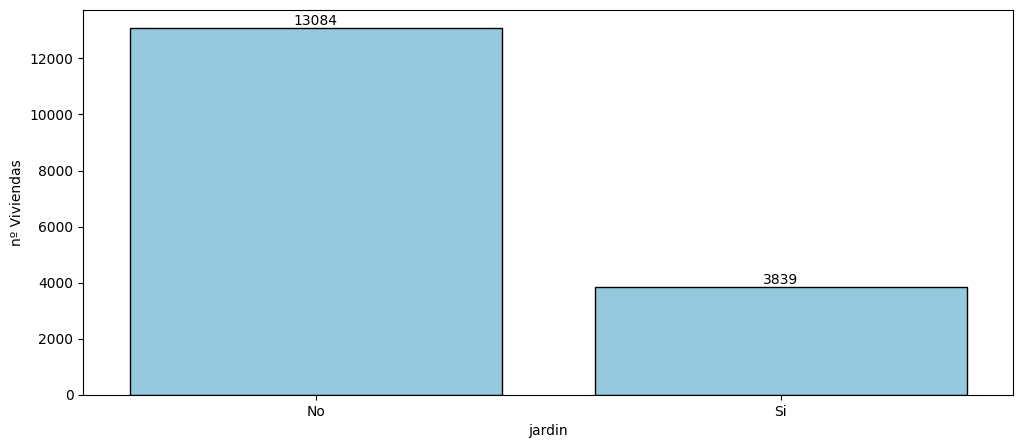

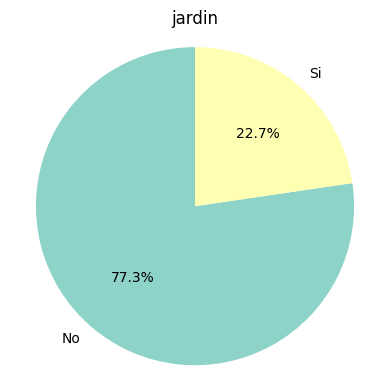

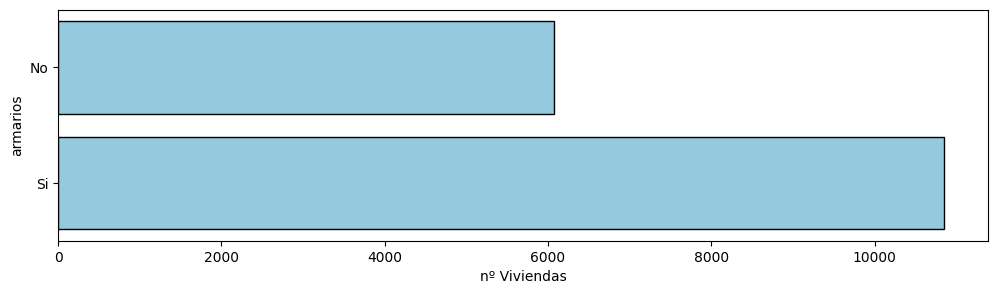

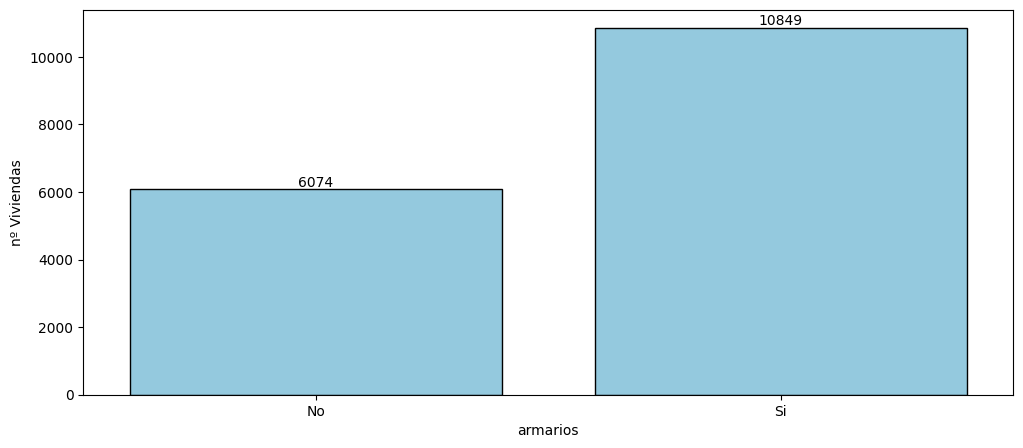

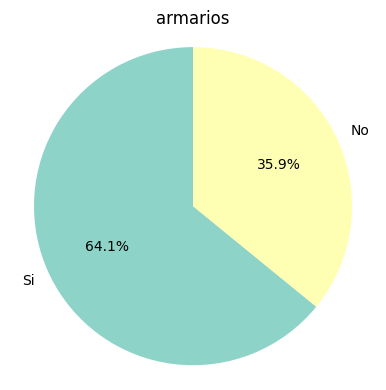

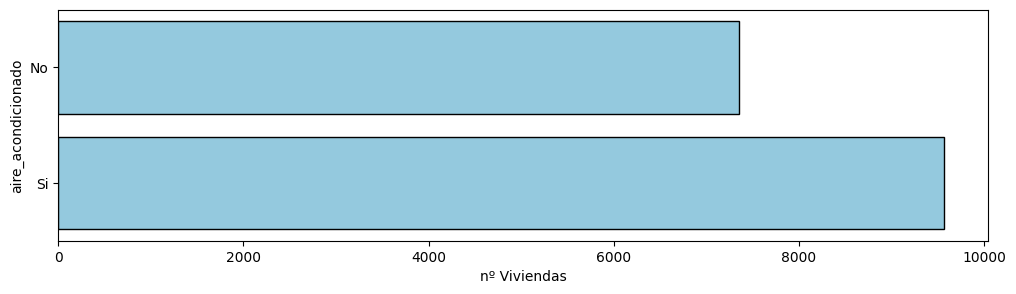

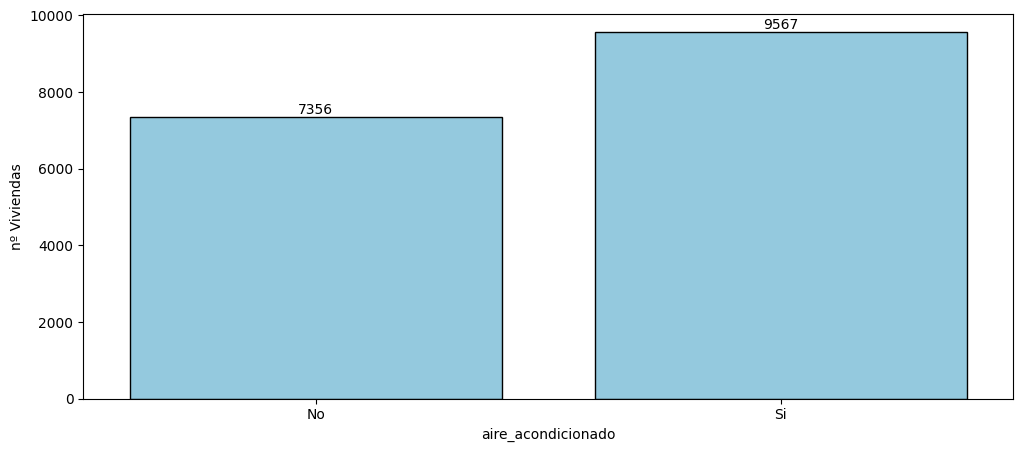

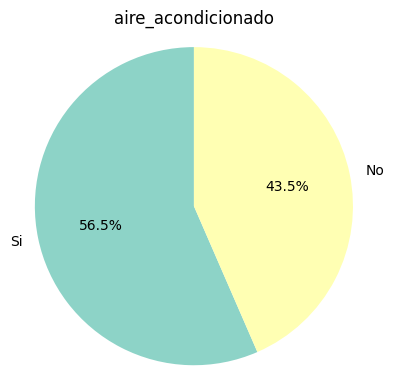

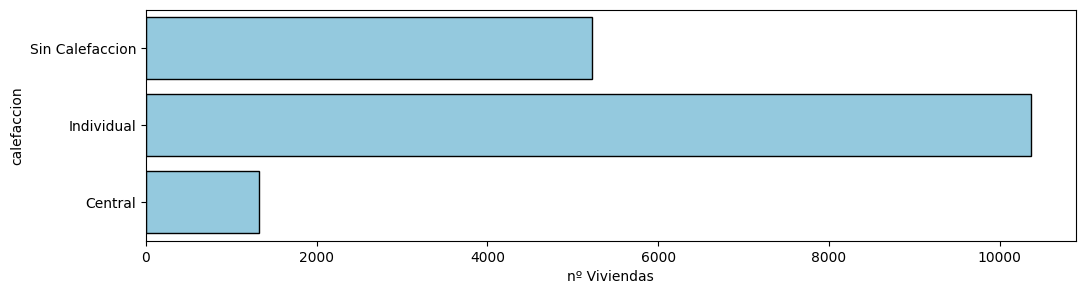

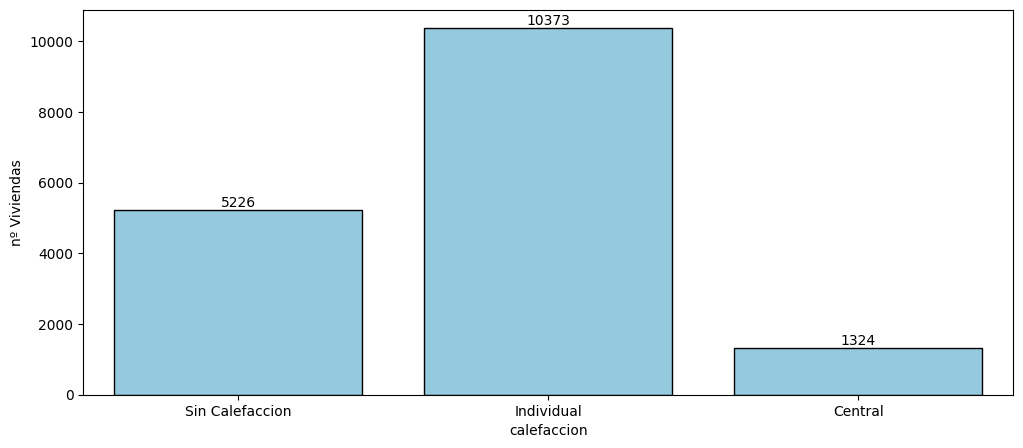

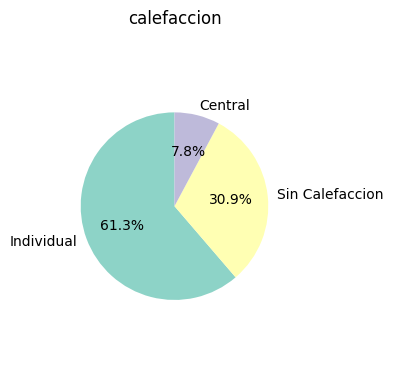

In [81]:

variables_categoricas = ["vivienda_unifamiliar", "tipo_vivienda", "estado", "interior", "ascensor", "piscina", "trastero", "garaje", "terraza", "balcon", 
                         "jardin", "armarios", "aire_acondicionado", "calefaccion"]
                         
for var in variables_categoricas:

    # BARRAS HORIZONTA
    plt.figure(figsize=(12, 3))
    sns.countplot(data_kdd[var], color='skyblue', edgecolor='black')
    plt.xlabel('nº Viviendas')
    plt.ylabel(var)

    
    #HISTPLOT
    #plt.figure(figsize=(12, 3))
    #sns.histplot(data_kdd[var], color='skyblue', edgecolor='black')
    #plt.xlabel(var)
    #plt.ylabel('nº Viviendas')

    # BARRAS VERTICAL CON ETIQUETAS/VOLUMEN
    plt.figure(figsize=(12, 5))
    ax = sns.countplot(x=var, data=data_kdd, color='skyblue', edgecolor='black')
    plt.xlabel(var)
    plt.ylabel('nº Viviendas')
    
    # Añadir etiquetas con los valores de cada barra
    for p in ax.patches:
        height = p.get_height()  # altura de la barra
        ax.text(
                x=p.get_x() + p.get_width() / 2,  # posición horizontal en el centro de la barra
                y=height + 0.5,                   # posición vertical un poco encima
                s=f'{int(height)}',               # texto a mostrar
                ha='center',                      # alinea horizontal
                va='bottom',                      # alinea vertical
                fontsize=10
        )
    plt.show()


    
    #PIE CHART
    conteo = data_kdd[var].value_counts()
    etiquetas = conteo.index
    valores = conteo.values
    plt.figure(figsize=(4, 4))
    plt.pie(valores,
            labels=etiquetas,
            autopct='%1.1f%%',  # Muestra el porcentaje con 1 decimal
            startangle=90,
            colors=plt.cm.Set3.colors)  # Paleta de colores agradable
    plt.title(var)
    plt.axis('equal')  # Mantiene forma de círculo
    plt.tight_layout()
    plt.show()



CONCLUSION ANALISIS REVISION VARIABLES

Tras la depuración y limpieza exhaustiva de los datos, el análisis de cada variable numérica no muestra irregularidades significativas; todos los registros se encuentran dentro de los rangos esperados y los valores extremos ya fueron tratados en la fase de outliers y filtrado por criterios de dominio. Por tanto, no se identifican inconsistencias que requieran intervención adicional en estas variables.

Sin embargo, algunas variables categóricas pueden presentar una distribución muy desigual entre categorías, lo que podría afectar al ajuste de los modelos de predicción. Un ejemplo relevante es la variable “interior”, cuya representación de valores está claramente sesgada hacia una categoría predominante. Esta heterogeneidad se tendrá en cuenta al preparar los modelos, pues puede requerir técnicas de ponderación, muestreo o codificación específica para evitar sesgos.

Para la visualización:

--Las variables numéricas se resumen mediante tablas de estadísticos básicos (mínimo, máximo, media) por tipo de vivienda y para el conjunto total.

--Las variables categóricas se presentan mediante gráficos de barras y gráficos circulares, incluyendo la indicación de frecuencia de cada categoría, facilitando la identificación de posibles desequilibrios.


**Detección de Correlaciones entre variables. Seleccion de variables**

Para la preparación de datos y la selección final de variables, se ha decidido abordar el análisis de correlaciones de manera diferenciada según el tipo de variable. Esto se debe a que las variables numéricas y las categóricas, una vez convertidas a dummies, presentan naturalezas estadísticas distintas y no es adecuado mezclarlas directamente en un mismo cálculo de correlación sin control.

Variables numéricas: presentan valores continuos con escalas comparables y permiten analizar relaciones lineales mediante correlación de Pearson, identificando posibles multicolinealidades o redundancias entre características que podrían afectar al ajuste de los modelos de regresión.

Variables categóricas convertidas a dummies: representan presencia o ausencia de una categoría específica mediante valores 0, 1, 2... Su análisis de correlación, especialmente respecto a la variable objetivo (precio) o entre sí, permite detectar categorías poco representativas, redundantes o altamente correlacionadas que podrían sesgar el modelo.

Al tratar cada tipo de variable por separado, se garantiza un análisis más coherente y riguroso, evitando interpretaciones erróneas de la correlación y facilitando la selección de un conjunto final de variables homogéneo y representativo para los modelos de predicción. Una vez analizadas por separado, las variables seleccionadas se integrarán en un único dataframe final para la construcción del modelo, asegurando que las relaciones detectadas se reflejen correctamente sin introducir multicolinealidad ni sesgos por desequilibrio en la representación de categorías.

--ANALISIS VARIABLES NUMERICAS

--ANALISIS VARIABLES CATEGORIAS / dummies -> *INTRODUCIR DEFINICION DUMMIES Y PROCESO


CORRELACIÓN VARIABLES NUMERICAS

In [82]:
data_numeric = data_kdd[var_numericas]

# Veamos la correlación entre todas las variables. 
correlations = data_numeric.corr()
print(correlations)

                            precio  metros_cuadrados_totales  \
precio                    1.000000                  0.529636   
metros_cuadrados_totales  0.529636                  1.000000   
metros_cuadrados_utiles   0.556015                  0.963368   
numero_baNos              0.613824                  0.777150   
numero_habitaciones       0.342469                  0.693531   
planta                    0.163988                 -0.179064   
antigUedad                0.178632                 -0.155289   

                          metros_cuadrados_utiles  numero_baNos  \
precio                                   0.556015      0.613824   
metros_cuadrados_totales                 0.963368      0.777150   
metros_cuadrados_utiles                  1.000000      0.797879   
numero_baNos                             0.797879      1.000000   
numero_habitaciones                      0.703889      0.692212   
planta                                  -0.178120     -0.105788   
antigUedad        

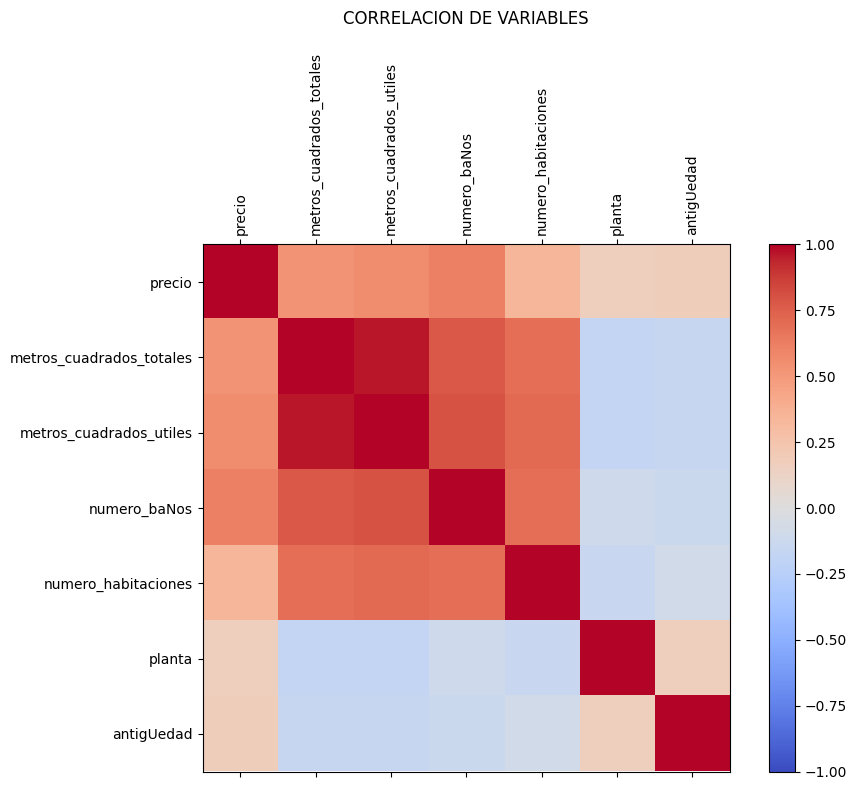

In [83]:

# Gráfico con la matriz de correlación entre todas las variables.

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(correlations, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(ticks=np.arange(len(correlations.columns)), labels=correlations.columns, rotation=90)
plt.yticks(ticks=np.arange(len(correlations.columns)), labels=correlations.columns)
plt.title("CORRELACION DE VARIABLES", pad=20)

# Agrega colorbar
fig.colorbar(cax)

plt.tight_layout()
plt.show()


<Axes: >

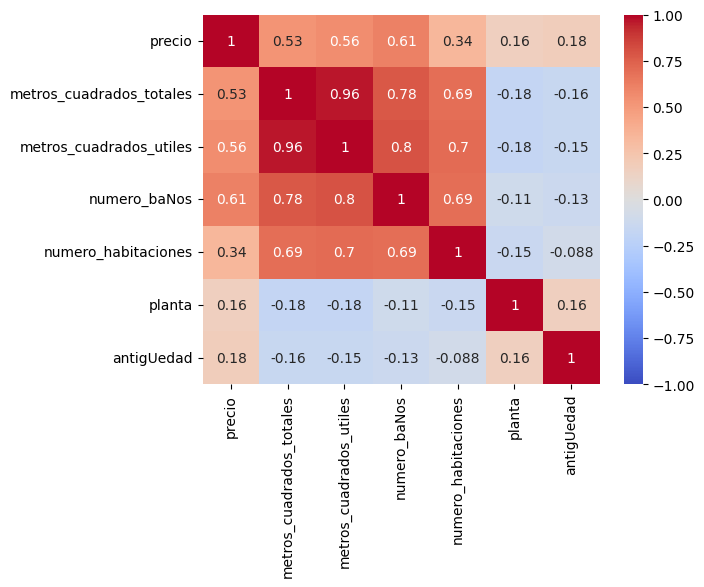

In [84]:

# Otro Gráfico con la matriz de correlación entre todas las variables.
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

Analizando la matriz de correlaciones podemos entender que las características que más pueden explicar la variable objetivo son:
-Numero de Baños (0.61)
-Metros cuadrados utiles (0.56)
-Metros cuadrados totales (0.53)
-Numeri de habitaciones (0.34)
-Antigüedad (0.18)
-Planta (0.16)

Es curioso, que el número de baños le importe tanto a la gente, que por supuesto tiene sentid por el coste de salidas/entradas de agua y su instalacion en general; además antes eran casas mas familiares donde se compartian más baños, habia menos culto al cuerpo y a la higiene incluso se tenían menos habitaciones... y ahora la gente busca más algo independiente, casi con baños ppor persona...entonces es algo normal)

-Comentar correlacion directa entre m2 utiles y totales. (0.96).
-Comentar correlacion demasiada del numero de habitaciones con el numero de baños (0.69) y m2 utiles (0.7). De hecho, ya habrá alta correlación entre estas 2 últimas y quizás haya que elegir 1 de las 2. Aunque el número de habitaciones depende más de los m2, por lo que tirar también por ahí. ¿LA DEJAMOS O NO?

-Comentar tambien el tema de la Antigüedad (correlación bajita), que los pisos más caros son más antiguos y seguro que tiene que ver por la zona. Ya que no es por el tamaño, pues on la correlacion de Antigüedad con los m2 es inversa (-0.15) lo que llama bastante la atención. Tiene pinta de que es porque hay muchos chalets más nuevos que están a las afueras de Madrid y son mucho más baratos, pero habría que intentar demostrarlo con un mapa o algo...o hacer algun filtro de información. DEMOSTRAR Y PELOTEARLO. ¿Hacemos algo o ya es demasiado para el TFM?

-La altura (numero de planta) no es muy explicativo, tiene una correlacion de 0.16 con el precio ya que puede haber chalets muy caros que son planta 0 o planta 1, pero la correlacion positiva confirma que la altura es una variable que aumenta el precio. Con el sesgo por supuesto de que puede haber casoplones entendidos como planta 0 que puede valer mucho dinero


---Hasta aquí, las variables numéricas a elegir serán "metros_cuadrados_utiles", "numero_baNos", "numero_habitaciones", "antigUedad" y "planta". 
DE MOMENTO INCLUIMOS "NUMERO_HABITACIONES" PERO SERÁ NECESARIO APLICAR PCA PARA EVITAR ALTAS CORRELACIONES ENTRE EL TRIPLETE "metros_cuadrados_utiles", "numero_baNos", "numero_habitaciones". De hecho, hay informaicón que dice que el número de habitaciones llega a "saturarse" porque a más habitaciones, más muros/paredes y eso reduce el espacio útil normalmente, entonces aquí siempre se busca la balanza por lo que "numero_habitaciones" puede tener algo de sesgo. A más m2 utiles quizás no quieres más habitaciones, si no una cocina más grande o un salón tambien grande para poder hacer comidas familiares o reuniones de amigos entre otros).

Casas más nuevas implican menos baños, menos habitaciones y menos metros cuadrados en general aunque contradice un poco el tema de que a mas antiguedad casas mas caras y de pisos mas altos...Entendiendo que chalets mas nuevos estan a las afueras y son bastante más baratos que pisos antiguos en el centro de Madrid donde la altura de los edificios es mayor. Aunque no sepamos defender esto a la perfección, tiene pinta 100% que es por la ubicación y por la tipologia de la vivienda. La tipologia de vivienda mas influyente son los pisos/edificios (62%), luego chalets un 27% y el resto de tipologiás de viviendas muy flojo ya que solo tienen el 11% y son otras 5 categoriss más.

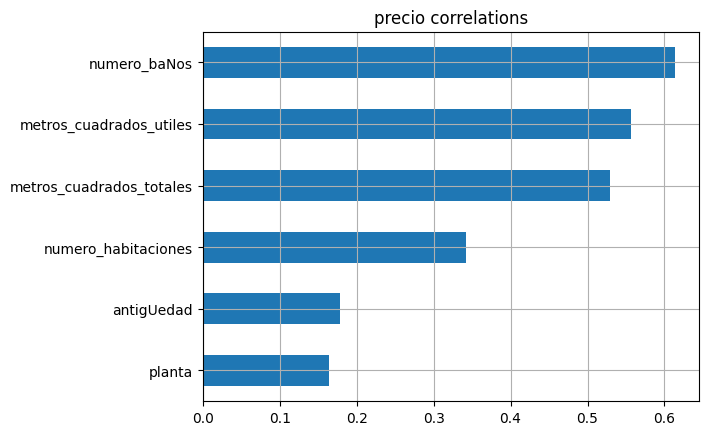

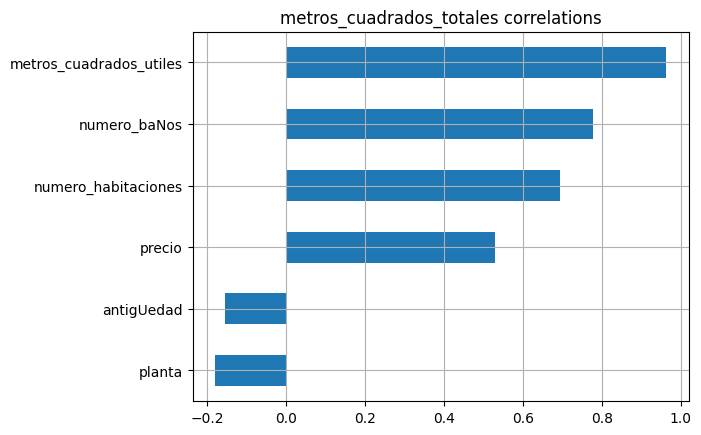

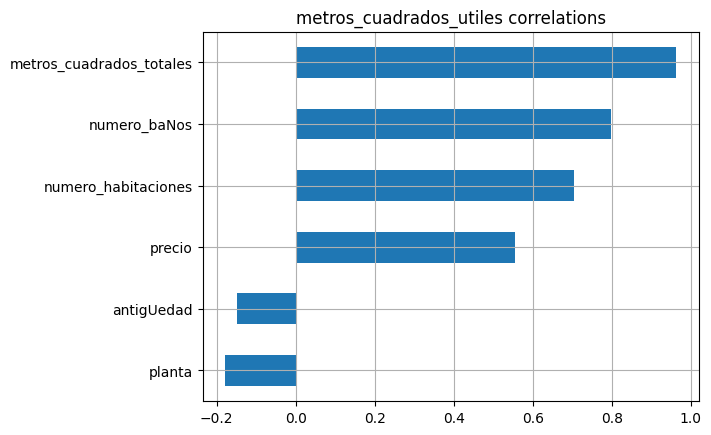

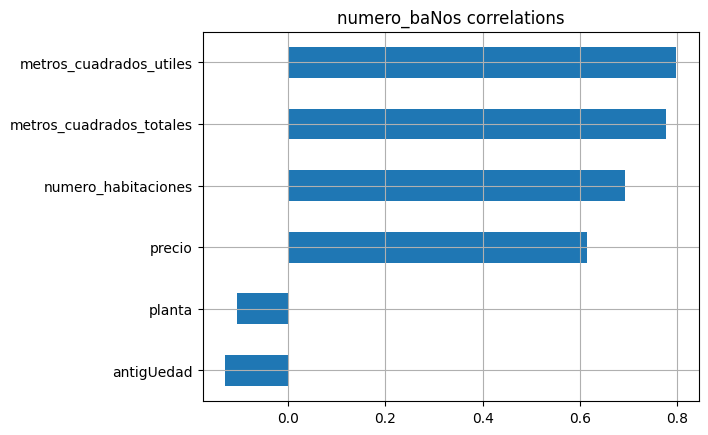

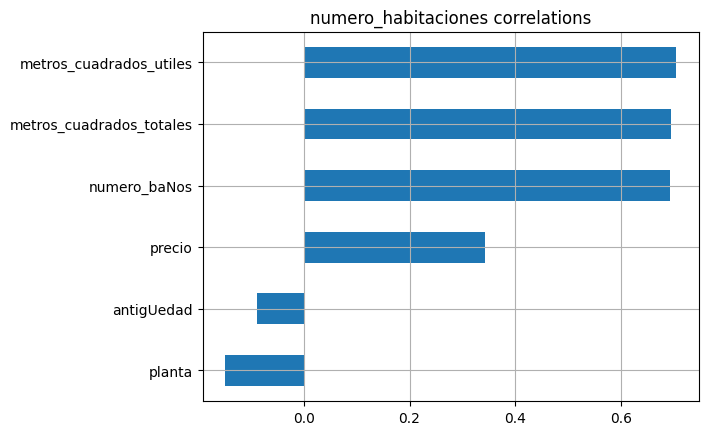

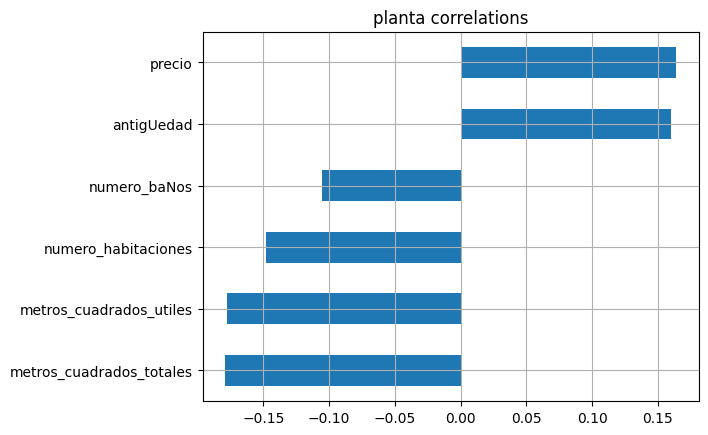

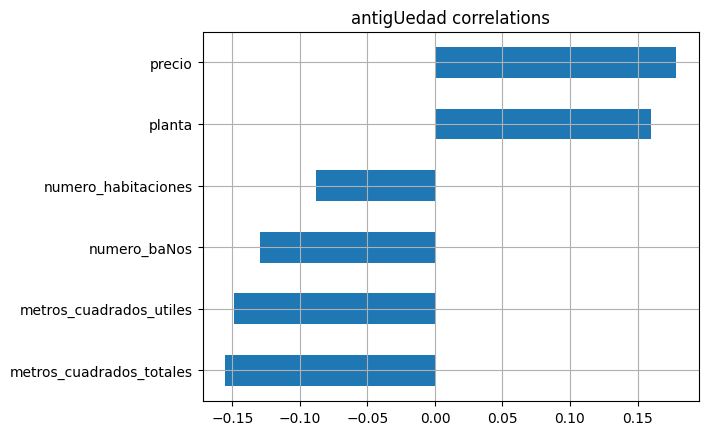

In [48]:
for var in data_numeric.columns:
    (correlations[var].sort_values(ascending=True).drop(var).plot.barh(title=f'{var} correlations', grid=True));
    plt.show()

<Axes: xlabel='metros_cuadrados_totales', ylabel='metros_cuadrados_utiles'>

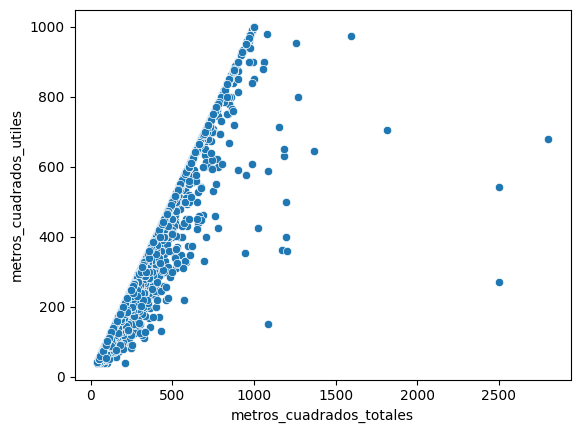

In [49]:
# m2 Totales vs Utiles
sns.scatterplot(data=data_kdd, x='metros_cuadrados_totales', y='metros_cuadrados_utiles')

<Axes: xlabel='metros_cuadrados_totales', ylabel='numero_baNos'>

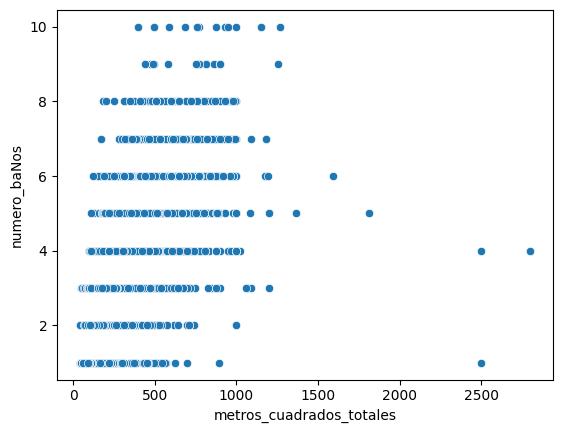

In [50]:
# m2 Totales vs Numero de Baños ¿PINTAR BOXPLOT?
sns.scatterplot(data=data_kdd, x='metros_cuadrados_totales', y='numero_baNos')

<Axes: xlabel='metros_cuadrados_utiles', ylabel='numero_baNos'>

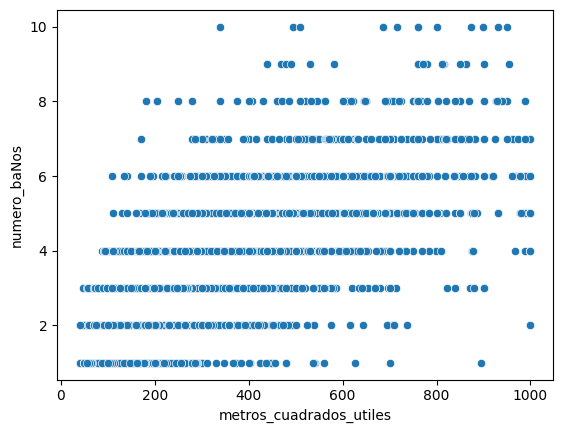

In [51]:
# m2 Utiles vs Numero de Baños ¿PINTAR BOXPLOT?
sns.scatterplot(data=data_kdd, x='metros_cuadrados_utiles', y='numero_baNos')

<Axes: xlabel='metros_cuadrados_totales', ylabel='numero_habitaciones'>

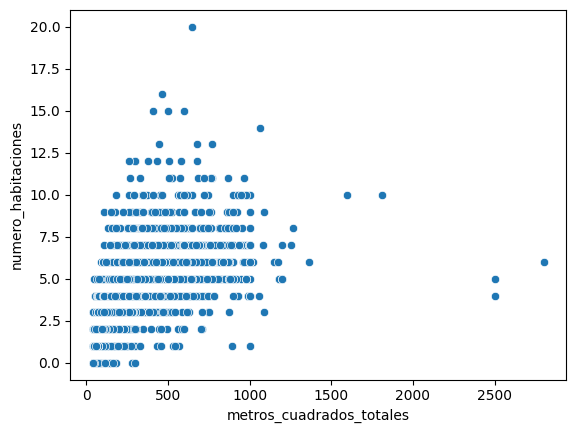

In [52]:
# m2 Totales vs Numero de Habitaciones 
sns.scatterplot(data=data_kdd, x='metros_cuadrados_totales', y='numero_habitaciones')

<Axes: xlabel='metros_cuadrados_utiles', ylabel='numero_habitaciones'>

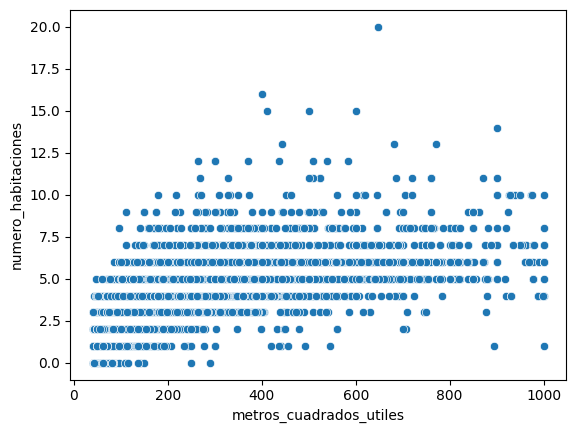

In [53]:
# m2 Utiles vs Numero de Habitaciones 
sns.scatterplot(data=data_kdd, x='metros_cuadrados_utiles', y='numero_habitaciones')

<Axes: xlabel='numero_habitaciones', ylabel='numero_baNos'>

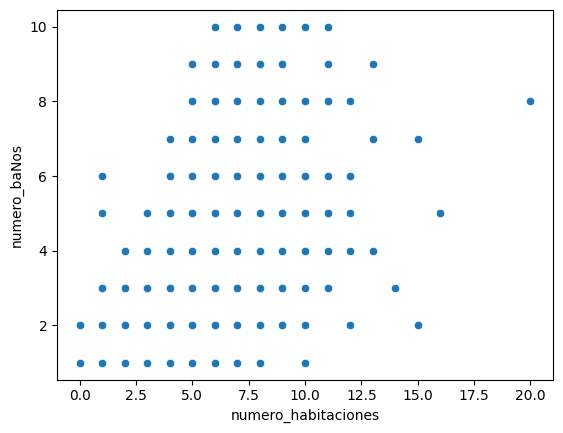

In [54]:
# Numero de habitaciones vs Numero de Baños
sns.scatterplot(data=data_kdd, y='numero_baNos', x='numero_habitaciones')

<Axes: xlabel='numero_baNos', ylabel='numero_habitaciones'>

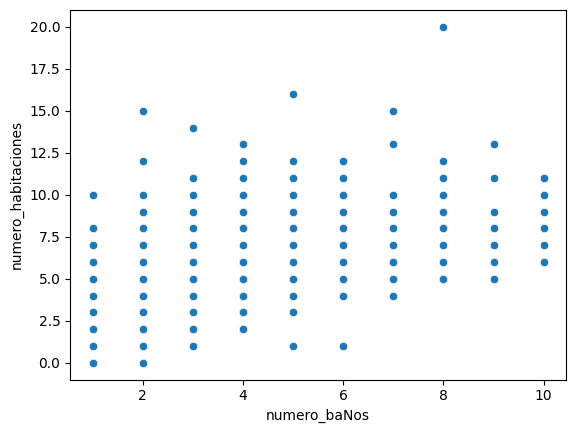

In [55]:
# Numero de Baños vs Numero de Habitaciones
sns.scatterplot(data=data_kdd, x='numero_baNos', y='numero_habitaciones')

Text(0, 0.5, 'Numero de Habitaciones')

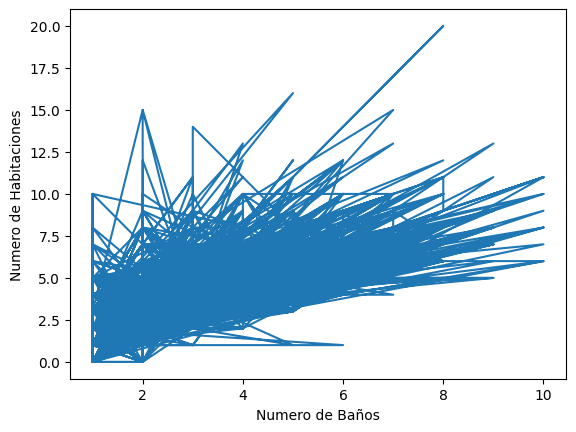

In [56]:
# Numero de Baños vs Numero de Habitaciones
plt.plot(data_kdd["numero_baNos"],data_kdd["numero_habitaciones"])
plt.xlabel("Numero de Baños")
plt.ylabel("Numero de Habitaciones")

CONCLUSION VARIABLES NUMERICAS

-Se decide eliminar metros_cuadrados_totales, debido a su alta correlación con metros_cuadrados_utiles, priorizando esta última por ser una medida más representativa del espacio habitable.

-Se mantiene numero_habitaciones, aunque presenta correlación con otras variables, ya que aporta información funcional relevante sobre la distribución de la vivienda.


CORRELACION VARIABLES CATEGÓRICAS USANDO DUMMIES

/var/folders/jq/vg6hqkr57rbbsd6xq59b8l940000gn/T/ipykernel_87681/806899010.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette="coolwarm")


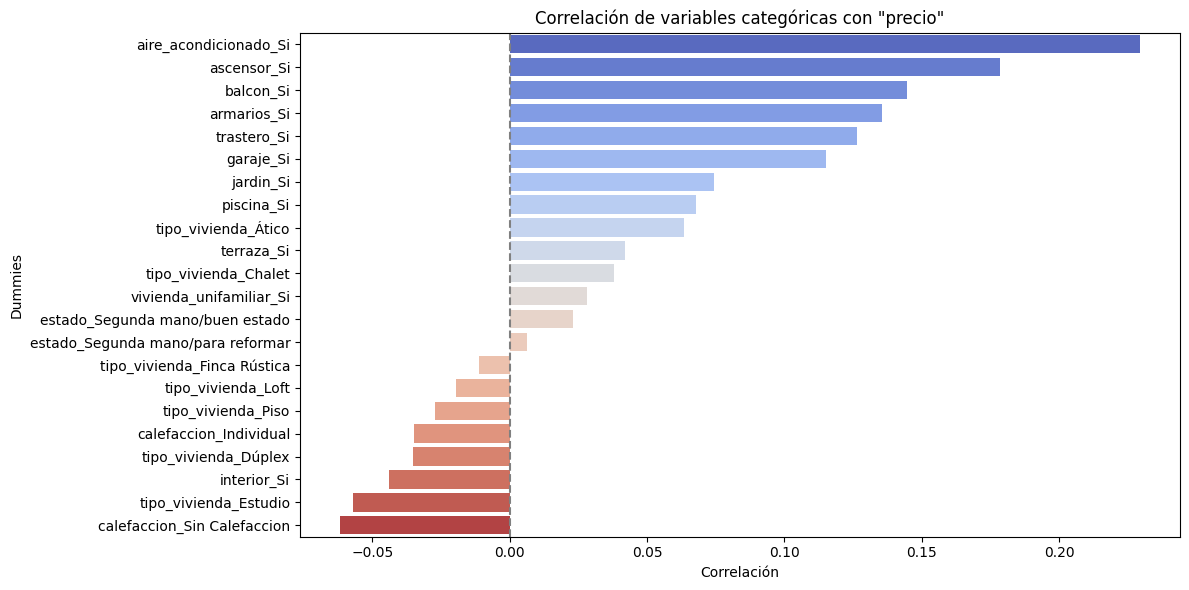

aire_acondicionado_Si                0.229383
ascensor_Si                          0.178535
balcon_Si                            0.144658
armarios_Si                          0.135491
trastero_Si                          0.126275
garaje_Si                            0.115029
jardin_Si                            0.074497
piscina_Si                           0.067862
tipo_vivienda_Ático                  0.063362
terraza_Si                           0.041857
tipo_vivienda_Chalet                 0.038134
vivienda_unifamiliar_Si              0.028129
estado_Segunda mano/buen estado      0.023015
estado_Segunda mano/para reformar    0.006340
tipo_vivienda_Finca Rústica         -0.011296
tipo_vivienda_Loft                  -0.019456
tipo_vivienda_Piso                  -0.026987
calefaccion_Individual              -0.034648
tipo_vivienda_Dúplex                -0.035328
interior_Si                         -0.044035
tipo_vivienda_Estudio               -0.057069
calefaccion_Sin Calefaccion       

In [ ]:
def plot_correlaciones_dummies(df, variables_cat, objetivo):
    """
    Crea dummies para variables categóricas, calcula su correlación con una variable numérica
    y pinta un gráfico ordenado de barras.

    Parámetros:
    - df: DataFrame original
    - variables_cat: lista de nombres de columnas categóricas
    - objetivo: nombre de la columna numérica objetivo
    """
    # Crear dummies
    dummies = pd.get_dummies(df[variables_cat], drop_first=True, prefix=variables_cat)
    
    # Calcular correlaciones
    correlaciones = dummies.corrwith(df[objetivo]).sort_values(ascending=False)
    
    # Gráfico
    plt.figure(figsize=(12, 6))
    sns.barplot(x=correlaciones.values, y=correlaciones.index, palette="coolwarm")
    plt.title(f'Correlación de variables categóricas con "{objetivo}"')
    plt.xlabel('Correlación')
    plt.ylabel('Dummies')
    plt.axvline(0, color='gray', linestyle='--')
    plt.tight_layout()
    plt.show()
    
    return correlaciones  # Opcional: para ver los valores numéricos

plot_correlaciones_dummies(data_kdd, variables_categoricas, 'precio')



--DESARROLLAR MUCHO MÁS DE COMO FUNCIONA LO DE LOS DUMMIES Y PORQUE, AQUÍ HAY BASTANTE DE QUE HABLAR EN CUANTO A VARIABLES YA QUE HAY MUCHA CHICHA QUE SE DEFIENDE CON LA "ZONA" que es en lo que nos queremos centrar...COMENTAR SESGO DE LAS ZONAS, QUE LA MAYORÍA (cerca del 45%) son pisos en edificios de Madrid Municipio.

Analizando la matriz de correlaciones nos damos cuenta que las variables categorícas son mucho menos explicativas que las variables numéricas y esto viene totalmente condicionado por la zona. ¿Se puede defender/explicar de algun modo?

CORRELACIONES
aire_acondicionado_Si                0.229383
ascensor_Si                          0.178535
balcon_Si                            0.144658
armarios_Si                          0.135491
trastero_Si                          0.126275
garaje_Si                            0.115029
jardin_Si                            0.074497
piscina_Si                           0.067862
tipo_vivienda_Ático                  0.063362
terraza_Si                           0.041857
tipo_vivienda_Chalet                 0.038134
vivienda_unifamiliar_Si              0.028129
estado_Segunda mano/buen estado      0.023015
estado_Segunda mano/para reformar    0.006340
tipo_vivienda_Finca Rústica         -0.011296
tipo_vivienda_Loft                  -0.019456
tipo_vivienda_Piso                  -0.026987
calefaccion_Individual              -0.034648
tipo_vivienda_Dúplex                -0.035328
interior_Si                         -0.044035
tipo_vivienda_Estudio               -0.057069
calefaccion_Sin Calefaccion         -0.061707

-Las variables  "aire_acondicionado", "ascensor", "balcon", "armarios", "trastero" y "garaje"  tienen más de 0.1 de correlación, y aunque es bastante poco, seguramente aportan su granito de arena para explicar la variable objetivo. Son comodidades que no dependen tanto de los "m2" útiles, por lo que nos las quedaremos seguro para transformarlas en dummies y lanzar de nuevo el análisis de correlaciones ya con el resto de las variables. Además, son variable sbooleanas que claramente son "comodidades" para el residente, por lo que a mayor comodidades, mayor precio.




--SESGO DE LA ZONA Y DE LAS CATEGORÍAS.
"tipo_vivienda"
-Ofrece muy poca correlación puesto que depende de otras características de la vivienda con más peso y que no dependa tanto de la zona. Por ejemplo, los chalets quizás no disparán tanto el precio, ya que aún teniéndo mayor superficie habitable, son más baratos porque estan a las afueras de Madrid (auqnue ojo cuidado con esto que puede haber zonas prefiféricss muy caras, de millonarios, aunque este tipo de vivienda se ha tratado de descartar). Los áticos si que es un formato más caro y suele ser más común en Madrid ciudad (además suelen ser pisos más grandes de lo normal por lo que se fortalece esta hipótesis). Aunque no con claridad total, si se nota que las tipologias más caras son Ático y después Chalets, continuando por Finca Rustica, Lof y Piso que incluso tienen correlacion negativa pero muy cercanas a 0. Todas tienen correlación absoluta menor que 0.1, lo que indica claramente que esta variable no define mucho el precio ya que es el formato de la vivienda, pero la realidad es que son mas relevantes otras características que definen de manera intrínseca la tipologia de la vivienda (como su tamaño y su infraestructura). La tipologia de vivienda mas frecuente son los pisos/edificios (62%), luego chalets un 27% y el resto de tipologiás de viviendas muy flojo ya que solo tienen el 11% y son otras 5 categorias más..Por ello esta variable esta bastante sesgada y por supuesto esto influye con la ubicacion.

"vivienda_unifamiliar" 
-Una vivienda unifamiliar suele ser más grande, por lo que más metros cuadrados útiles, y ya hemos visto que a más m2 utiles, mayor precio, por lo que como no era de otra forma, esta variable tiene una correlacion positiva, pero muy pequeña, seguro por sesgo de la zona.

"estado"
-Tambien es llamativo lo del "estado", que influye bastante poco y en realidad es algo bastante importante. Es porque es una variable muy sesgada, pues más del 75% de las viviendas están clasificadas como "buen estado" por lo que pesa demasiado y no da opción a explicar demasiado el "precio" de la vivienda aunque por supuesto es una característica importante a tener en cuenta.

"interior"
-Con la variable "interior" sucede lo mismo. Es poco explicativa, pues la mayoría es "exterior" y seguramente lo poco que sea "interior" está en Madrid ciudad y eso hace que sean más caros de lo habitual aunque por supuesto, siempre buscamos viviendas con ventana y buenas vistas.

"piscina", "jardin" y "terraza"
-Comentamos también el tema de la piscina o el jardin que es bastante llamativo pues casi no hay correlacion y encima es negativa. Seguramente esto sucede por el sesgo de las zonas, que marcará mucho el precio de la vivienda. DESARROLLAR MÁS (variables sesgadas, SI es menoría y depende de la zona...). ¿Las incluimos cuando metamos variables geo? ¿tiene sentido? Tendría sentido cuando comparemos unos chalets con otros, ya que ahi marcará diferencia, pero al final los pisos de Madrid centro son mucho más caros que un chalet a las afueras del sur de Madrid aunque tenga piscina y jardín. Aquí podemos explicar que las variables "jardin" y "piscina",  teniendo una correlación positiva bajita menores de 0.1 pero mayores a 0.04; claramente representan servicios adicionales que son de interés para el residente y normalmente hacen que el precio suba independientemente de la zona.
¿DESCARTADAS SI NO SE TIENE MODELO POR ZONA? ¿O es interesante mantenerlas?

"calefaccion"
-Este dato si que confunde bastante ya que es una comodidad que no depende de los m2 y por supuesto es una característica a tener en cuenta. Si que es cierto que está un poco desbalanceada a favor de "calefaccion_individual" 60% mientras que "sin_calefaccion" se tendría un 30%. El problema es que la pequeña correlación que existe, encima es negativa, por lo que 100% es una característica que debe estar muy acusada por la zona y no nos va a servir para el modelo.



---SELECCION DE VARIABLES
-Viendo el gran sesgo que tiene las categorías, es muy probable que muchas de ellas empeoren el modelo, por lo que será mejor descartarlas.
Quedandonos con variables con correlacion mayor que 0.1: "aire_acondicionado", "ascensor", "balcon", "armarios", "trastero" y "garaje"
Mantendremos también las variables "piscina", "jardin" y "terraza" que están bastante balanceadas y son importantes a la hora de comprar una vivienda, aunque a priori no tengan mucha correlación con el "precio".

CORRELACION VARIABLES DEFINITIVAS UNIFICANDO VARS_NUM_DEF CON VARS_CAT_DEF (dummies)

In [93]:
variables_categoricas_df = ['aire_acondicionado', 'ascensor',
        'piscina', 'trastero', 'garaje', 'terraza', 'balcon', 'jardin', 'armarios']

var_numericas_df = ['precio', 'metros_cuadrados_utiles','numero_baNos', 'numero_habitaciones', 'planta', 'antigUedad']

cat_dummies = pd.get_dummies(data_kdd[variables_categoricas_df], drop_first=True)

data_corr = pd.concat([data_kdd[var_numericas_df], cat_dummies], axis=1)

corr_matrix = data_corr.corr()

print(corr_matrix)


                           precio  metros_cuadrados_utiles  numero_baNos  \
precio                   1.000000                 0.556015      0.613824   
metros_cuadrados_utiles  0.556015                 1.000000      0.797879   
numero_baNos             0.613824                 0.797879      1.000000   
numero_habitaciones      0.342469                 0.703889      0.692212   
planta                   0.163988                -0.178120     -0.105788   
antigUedad               0.178632                -0.149159     -0.129487   
aire_acondicionado_Si    0.229383                 0.065024      0.157596   
ascensor_Si              0.178535                -0.322013     -0.189846   
piscina_Si               0.067862                 0.372722      0.353826   
trastero_Si              0.126275                 0.285971      0.291184   
garaje_Si                0.115029                 0.350809      0.365361   
terraza_Si               0.041857                 0.218330      0.205793   
balcon_Si   

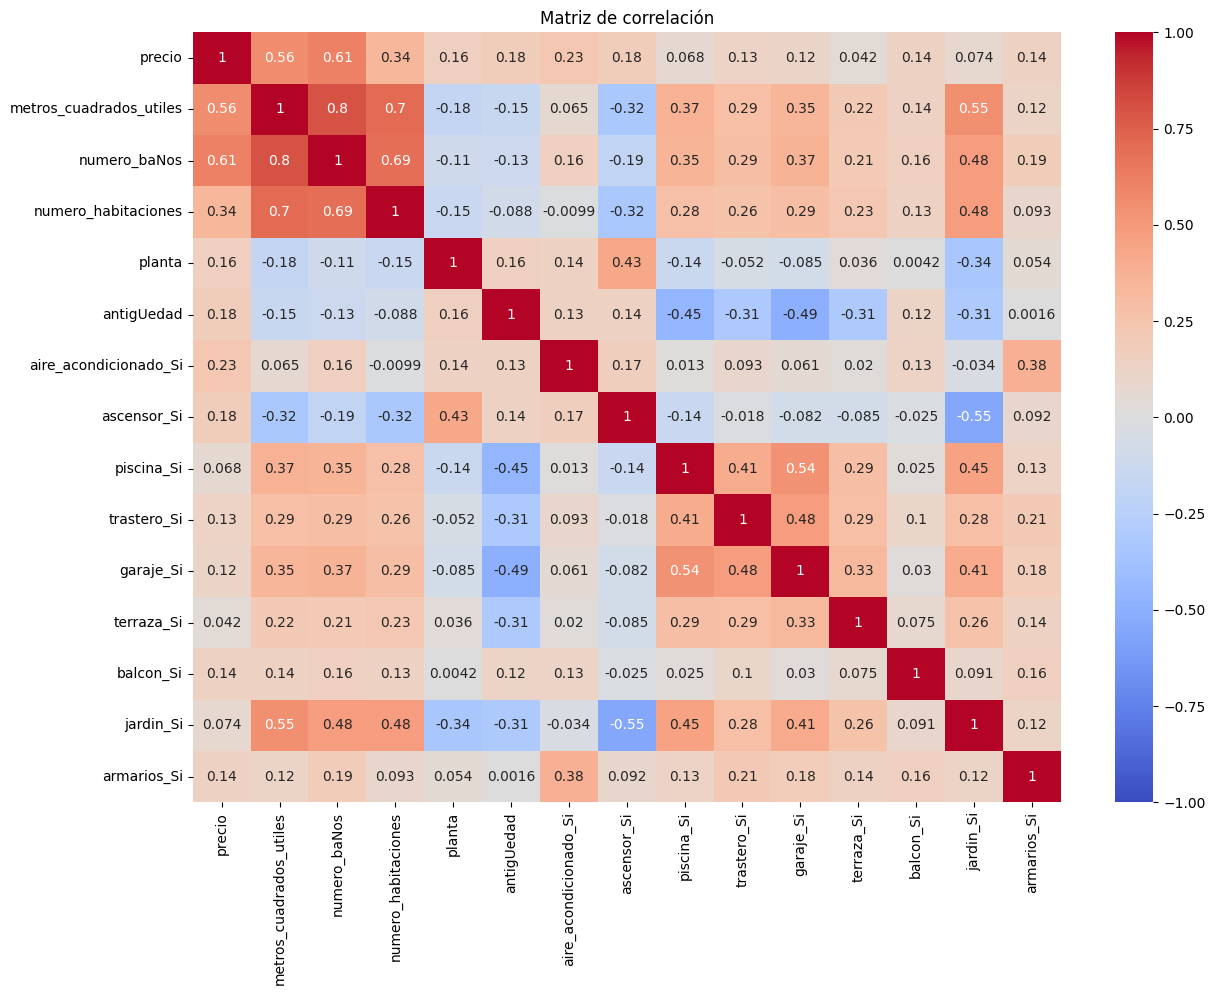

In [94]:
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.show()

CONCLUSION Y SELECCION DEFINITIVA DE VARIABLES

-Se aprecian ciertas relaciones que evidencian la veracidad de los datos: como por ejemplo la correlaicon positiva entre plantia y ascensor.

-Solo se descarta la variable "terraza" por tener una correlación demasiado débil con el precio y que se explica mediante otras características como "jardin", "piscina", "garaje" y "trastero".

-El resto de variables se mantienen pero:
i) Las características jardin y piscina tienen una correlación irrelevante con el precio (correlación menor a 0.1)
ii) Las variables metros cuadrados útiles, numero de baños y número de habitaciones tienen una alta correlación (mayor a 0.5) entre las 3 pero no superior a 0.8
iii) Las variables psicina, trastero, garaje, jardin también presentan clara correlaicón entre ellas y con la superficie de la vivienda.

Evidentemente siempre se asume algo de multicolinealidad, por lo que será esencial aplicar un PCA y reducir sesgos relacionales entre variables.

In [95]:
data_corr = data_corr.drop(columns=['terraza_Si'])

# Vista de los tipos de datos y el tamaño del dataset (filas/registros y columnas/atributos).

data_corr.info()

print("-------------------------------------")
print(f"Cantidad de filas: {data_corr.shape[0]}")
print(f"Cantidad de columnas: {data_corr.shape[1]}")

print(data_corr.columns)

<class 'pandas.core.frame.DataFrame'>
Index: 16923 entries, 1 to 19444
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   precio                   16923 non-null  int64
 1   metros_cuadrados_utiles  16923 non-null  int64
 2   numero_baNos             16923 non-null  int64
 3   numero_habitaciones      16923 non-null  int64
 4   planta                   16923 non-null  int64
 5   antigUedad               16923 non-null  int64
 6   aire_acondicionado_Si    16923 non-null  bool 
 7   ascensor_Si              16923 non-null  bool 
 8   piscina_Si               16923 non-null  bool 
 9   trastero_Si              16923 non-null  bool 
 10  garaje_Si                16923 non-null  bool 
 11  balcon_Si                16923 non-null  bool 
 12  jardin_Si                16923 non-null  bool 
 13  armarios_Si              16923 non-null  bool 
dtypes: bool(8), int64(6)
memory usage: 1.0 MB
-----------------

In [ ]:

#Exportar los datos tratados hasta el momento
#data_corr.to_csv('CasasEnVenta_Madrid_KDD.csv', sep=';', decimal='.')